In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('src'))
import edn_popdyn.paths
from edn_popdyn.paths import (
    FIGURES_DIR, STATS_CSV_DIR,
)

In [2]:
from edn_popdyn import colors as pal 

# 3.1 — Population geometry model

Fit the population-geometry model and compare valid vs invalid null- and potent-space structure.

## Model equations

**Latent dynamics**:
$$x_{t+1} = A\,x_t + u_t + \varepsilon_t,\qquad \varepsilon_t \sim \mathcal{N}(0, \sigma_t^2 I_K)$$

**Readout** (time-varying):
$$r_t = g\,W(t)\,x_t,\qquad W(t) = (1-\alpha_t)\,W_\mathrm{pre} + \alpha_t\,W_\mathrm{post}^{(c,s)}$$

with $\alpha_t = 0$ for $t<t_0$ and $\alpha_t = 1 - e^{-(t-t_0)/\tau_\mathrm{rot}}$ for $t\ge t_0$.

**Task-potent axis** (in activity space):
$$u_\mathrm{task} \;=\; \frac{W_\mathrm{base}[:,0] - W_\mathrm{base}[:,1]}{\|\cdot\|}$$

This is the direction along which category-A (stim-1) and category-B (stim-2) mean
responses differ: the stimulus drives $d^{(1)} \propto e_1$ and $d^{(2)} \propto e_2$
enter latent dim 0 and 1, so $W_\mathrm{base}[:,0]-W_\mathrm{base}[:,1]$ is the direction
in $\mathbb{R}^N$ that carries categorization information.

Projection operators:
$$P_\mathrm{pot} = u_\mathrm{task}\,u_\mathrm{task}^\top,\qquad P_\mathrm{null} = I - P_\mathrm{pot}$$

**Identity remap with explicit null/potent split**:
$$J^{(c)} = \sigma_\mathrm{null}^{(c)}\,P_\mathrm{null}\,\xi_\mathrm{null}
         + \sigma_\mathrm{pot}^{(c)} \,P_\mathrm{pot} \,\xi_\mathrm{pot}$$

with $\xi_\mathrm{null},\xi_\mathrm{pot}\sim\mathcal{N}(0,I)$ drawn independently.


## 0) Imports and plot style

In [3]:
import itertools
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys

from joblib import Parallel, delayed
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_1samp
from scipy.stats import wilcoxon, mannwhitneyu
from scipy.stats import wilcoxon, mannwhitneyu, rankdata, ttest_rel, ttest_1samp
from scipy.stats import wilcoxon, mannwhitneyu, ttest_1samp
from sklearn.decomposition import PCA
from sklearn.decomposition import PCA as _PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
invalid_color  = pal.invalid
valid_color    = pal.valid
cue_a_color    = pal.cue_a
cue_b_color    = pal.cue_b
target_a_color = pal.target_a
target_b_color = pal.target_b      

COL_VALID   = valid_color
COL_INVALID = invalid_color
COL_NC      = pal.nc_gray

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
})

## 1) Linear-algebra and simulation helpers


In [5]:
def orthonormal_matrix(n, k, rng):
    Q, _ = np.linalg.qr(rng.normal(size=(n, k)))
    return Q[:, :k]

def rotate_subspace(W, theta, rng):

    n, k = W.shape
    U_perp = orthonormal_matrix(n, k, rng)
    U_perp = U_perp - W @ (W.T @ U_perp)
    U_perp, _ = np.linalg.qr(U_perp)
    return W * np.cos(theta) + U_perp[:, :k] * np.sin(theta)

def simulate_latent_stepwise(A, x0, stim_drive, T, t0, noise_pre, noise_post, rng):
    K = A.shape[0]
    x = np.zeros((T, K))
    x[0] = x0
    for t in range(1, T):
        x[t] = A @ x[t-1] + stim_drive[t]
        noise = noise_pre if t < t0 else noise_post
        if noise > 0:
            x[t] += rng.normal(scale=noise, size=K)
    return x

def firing_from_latent(x, W, gain=1.0, baseline=13.0):

    return (x @ W.T + baseline) / gain

def null_potent_projectors(u_task):

    u = np.asarray(u_task, dtype=float).reshape(-1)
    u = u / (np.linalg.norm(u) + 1e-12)
    P_pot = np.outer(u, u)
    P_null = np.eye(u.size) - P_pot
    return P_null, P_pot, u

def _offdiag_means(S):
    n = S.shape[0]
    out = np.empty(n)
    for i in range(n):
        out[i] = (S[i].sum() - S[i, i]) / max(n - 1, 1)
    return out

def _despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 2) Main simulation with explicit null/potent remap

In [6]:
def main_null_potent(
    seed=1,
    N=100, K=3, T=60, NTR=400,
    t0=5, t1=55,
    tau_rot=10.0,

    theta_prep_deg=4.0,
    theta_target_shared_deg=6.0,

    prep_bias_mag=0.35,
    target_drive_mag=0.12,
    stim_identity_drive=0.04,

    sigma_null_mean_valid=0.20,
    sigma_null_mean_invalid=0.02,
    sigma_pot_mean_valid=0.005,
    sigma_pot_mean_invalid=0.30,

    sigma_null_trial_valid   = 0.35,
    sigma_null_trial_invalid = 0.02,
    sigma_pot_trial_valid    = 0.001,
    sigma_pot_trial_invalid  = 0.05,

    latent_noise_pre=0.010,
    latent_noise_valid_post=0.008,
    latent_noise_invalid_post=0.035,
    gain_cued=1.2,
    use_asymmetric_A=True,
):
    rng = np.random.default_rng(seed)

    if use_asymmetric_A:
        A = np.array([
            [0.992, 0.030, 0.000],
            [0.000, 0.955, 0.020],
            [0.010, 0.010, 0.980],
        ], dtype=float)
    else:
        A = np.eye(K) * 0.98 + 0.01 * rng.normal(size=(K, K))

    W_base = rng.normal(size=(N, K)) / np.sqrt(K)

    u_task = W_base[:, 0] - W_base[:, 1]
    u_task = u_task / (np.linalg.norm(u_task) + 1e-12)

    P_null, P_pot, u_task = null_potent_projectors(u_task)

    u_pot_latent = W_base.T @ u_task
    u_pot_latent = u_pot_latent / (np.linalg.norm(u_pot_latent) + 1e-12)

    v_res = rng.normal(size=K)
    v_res = v_res - (v_res @ u_pot_latent) * u_pot_latent
    v_res = v_res / (np.linalg.norm(v_res) + 1e-12)

    W_pre = rotate_subspace(W_base, np.deg2rad(theta_prep_deg), rng)
    W_tgt = rotate_subspace(W_base, np.deg2rad(theta_target_shared_deg), rng)

    def draw_J_mean(sigma_null, sigma_pot, shape):
        xi_n = rng.normal(size=shape); xi_p = rng.normal(size=shape)
        J_n = sigma_null * (P_null @ xi_n)
        J_p = sigma_pot  * (P_pot  @ xi_p)
        return J_n, J_p, J_n + J_p

    J_v_null_mean, J_v_pot_mean, J_v_mean = draw_J_mean(
        sigma_null_mean_valid, sigma_pot_mean_valid, W_base.shape
    )
    J_i_null_mean, J_i_pot_mean, J_i_mean = draw_J_mean(
        sigma_null_mean_invalid, sigma_pot_mean_invalid, W_base.shape
    )

    signs = np.sign(rng.standard_normal((N, 1)))

    per_trial_J = {'val1': [], 'val2': [], 'inv1': [], 'inv2': []}

    def gen_trials(cue_sign, target_sign, is_valid, key):

        stim_drive = np.zeros((T, K))
        stim_drive[t0:t1] = (
            target_sign * target_drive_mag * u_pot_latent[None, :]
            + target_sign * stim_identity_drive * v_res[None, :]
        )

        if is_valid:
            sig_n_trial = sigma_null_trial_valid
            sig_p_trial = sigma_pot_trial_valid
            J_mean_this = J_v_mean
            noise_post = latent_noise_valid_post

            tgt_flip = 1.0
        else:
            sig_n_trial = sigma_null_trial_invalid
            sig_p_trial = sigma_pot_trial_invalid
            J_mean_this = J_i_mean
            noise_post = latent_noise_invalid_post

            tgt_flip = float(target_sign)

        trials = []
        for _ in range(NTR):

            x0 = cue_sign * prep_bias_mag * u_pot_latent + 0.05 * rng.normal(size=K)
            x = simulate_latent_stepwise(
                A, x0, stim_drive, T, t0,
                noise_pre=latent_noise_pre,
                noise_post=noise_post,
                rng=rng,
            )

            xi_n = rng.normal(size=W_base.shape)
            xi_p = rng.normal(size=W_base.shape)
            J_n_trial = sig_n_trial * (P_null @ xi_n)
            J_p_trial = sig_p_trial * (P_pot  @ xi_p)

            J_trial = tgt_flip * J_mean_this + J_n_trial + J_p_trial
            per_trial_J[key].append(J_trial)

            W_post_trial = W_tgt + J_trial

            R = np.zeros((T, N))
            R[:t0] = firing_from_latent(x[:t0], W_pre, gain=gain_cued)
            for tt in range(t0, T):
                alpha = 1.0 - np.exp(-(tt - t0) / tau_rot) if tau_rot > 0 else 1.0
                W_t = (1 - alpha) * W_pre + alpha * W_post_trial
                R[tt] = firing_from_latent(x[tt:tt+1], W_t, gain=gain_cued)
            trials.append(R)
        return trials

    val1 = gen_trials(+1, +1, True,  'val1')
    val2 = gen_trials(-1, -1, True,  'val2')
    inv1 = gen_trials(+1, -1, False, 'inv1')
    inv2 = gen_trials(-1, +1, False, 'inv2')

    return dict(
        val1=val1, val2=val2, inv1=inv1, inv2=inv2,
        t0=t0, t1=t1, T=T, N=N, K=K, NTR=NTR, tau_rot=tau_rot,
        A=A, W_base=W_base, W_pre=W_pre, W_tgt=W_tgt,
        u_task=u_task, u_pot_latent=u_pot_latent, v_res=v_res,
        P_null=P_null, P_pot=P_pot,

        J_v_null=J_v_null_mean, J_v_pot=J_v_pot_mean, J_v_mean=J_v_mean,
        J_i_null=J_i_null_mean, J_i_pot=J_i_pot_mean, J_i_mean=J_i_mean,

        J_v_total=J_v_mean, J_i_total=J_i_mean,
        W_tgt_valid=W_tgt, W_tgt_invalid=W_tgt,
        signs=signs,
        per_trial_J=per_trial_J,
        params=dict(
            theta_prep_deg=theta_prep_deg,
            theta_target_shared_deg=theta_target_shared_deg,
            sigma_null_trial_valid=sigma_null_trial_valid,
            sigma_null_trial_invalid=sigma_null_trial_invalid,
            sigma_pot_trial_valid=sigma_pot_trial_valid,
            sigma_pot_trial_invalid=sigma_pot_trial_invalid,
        ),
    )

## 3) Run the simulation

In [7]:
out = main_null_potent(
    seed=22,
    N=100, K=3, T=60, NTR=600,
    t0=5, t1=55,
    tau_rot=10.0,
    theta_prep_deg=4.0,
    theta_target_shared_deg=6.0,

    prep_bias_mag=0.35,
    target_drive_mag=0.12,
    stim_identity_drive=0.04,

    sigma_null_mean_valid=0.20,
    sigma_null_mean_invalid=0.02,
    sigma_pot_mean_valid=0.005,
    sigma_pot_mean_invalid=0.30,

    sigma_null_trial_valid=0.160,
    sigma_null_trial_invalid=0.005,
    sigma_pot_trial_valid=0.001,
    sigma_pot_trial_invalid=2.0,
    latent_noise_pre=0.010,
    latent_noise_valid_post=0.008,
    latent_noise_invalid_post=0.020,
    gain_cued=1.2,
    use_asymmetric_A=True,
)

val1, val2 = out["val1"], out["val2"]
inv1, inv2 = out["inv1"], out["inv2"]
t0, t1, T  = out["t0"], out["t1"], out["T"]
N, K       = out["N"], out["K"]

print(f"Simulation complete: N={N} neurons, K={K} latent dims, T={T} bins")
print(f"Trials/condition: val1={len(val1)}, val2={len(val2)}, inv1={len(inv1)}, inv2={len(inv2)}")
print(f"u_task norm     = {np.linalg.norm(out['u_task']):.4f}")
print(f"u_pot_latent    = {np.round(out['u_pot_latent'], 3)}")
print(f"||J_v_null||_F  = {np.linalg.norm(out['J_v_null']):.4f}")
print(f"||J_v_pot||_F   = {np.linalg.norm(out['J_v_pot']):.4f}")
print(f"||J_i_null||_F  = {np.linalg.norm(out['J_i_null']):.4f}")
print(f"||J_i_pot||_F   = {np.linalg.norm(out['J_i_pot']):.4f}")

pt = out['per_trial_J']
for k in ['val1', 'val2', 'inv1', 'inv2']:
    Js = np.stack(pt[k])
    pn = np.array([np.linalg.norm(out['P_null'] @ J) for J in Js])
    pp = np.array([np.linalg.norm(out['P_pot']  @ J) for J in Js])
    print(f"  {k}: ||P_null J||={pn.mean():.3f}+-{pn.std():.3f},  ||P_pot J||={pp.mean():.3f}+-{pp.std():.3f}")

out_dir = f"{FIGURES_DIR}"
os.makedirs(out_dir, exist_ok=True)

Simulation complete: N=100 neurons, K=3 latent dims, T=60 bins
Trials/condition: val1=600, val2=600, inv1=600, inv2=600
u_task norm     = 1.0000
u_pot_latent    = [ 0.764 -0.635  0.113]
||J_v_null||_F  = 3.0837
||J_v_pot||_F   = 0.0066
||J_i_null||_F  = 0.3448
||J_i_pot||_F   = 0.3585
  val1: ||P_null J||=4.137+-0.141,  ||P_pot J||=0.007+-0.001
  val2: ||P_null J||=4.137+-0.141,  ||P_pot J||=0.007+-0.001
  inv1: ||P_null J||=0.355+-0.005,  ||P_pot J||=3.151+-1.354
  inv2: ||P_null J||=0.355+-0.005,  ||P_pot J||=3.243+-1.321


In [8]:
_BASE = dict(
    seed=22, N=100, K=3, T=60, NTR=200,
    t0=5, t1=55, tau_rot=10.0,
    theta_prep_deg=4.0, theta_target_shared_deg=6.0,
    prep_bias_mag=0.35, target_drive_mag=0.12, stim_identity_drive=0.04,
    sigma_null_mean_valid=0.20, sigma_null_mean_invalid=0.02,
    sigma_pot_mean_valid=0.005, sigma_pot_mean_invalid=0.30,
    sigma_null_trial_invalid=0.005, sigma_pot_trial_valid=0.001,
    sigma_pot_trial_invalid=2.0,
    latent_noise_pre=0.010, latent_noise_valid_post=0.008,
    latent_noise_invalid_post=0.020, gain_cued=1.2,
)

print('{:>6}  {:>10}  {:>10}  {:>6}  {:>10}  {}'.format(
    'sntv', 'sn_p(Wil)', 'pop_p(MWU)', 'frac', 'pop_delta', 'result'))
print('-' * 72)

for _sntv in [0.150, 0.155, 0.158, 0.159, 0.160, 0.161, 0.162, 0.165]:
    _o = main_null_potent(sigma_null_trial_valid=_sntv, **_BASE)
    _v1, _v2, _i1, _i2 = _o['val1'], _o['val2'], _o['inv1'], _o['inv2']
    _t0, _t1 = _o['t0'], _o['t1']

    _uv = np.empty(100); _ui = np.empty(100)
    for _n in range(100):
        def _pc(trs, n=_n):
            W = np.stack([tr[_t0:_t1, n] for tr in trs])
            W = W - W.mean(1, keepdims=True)
            nrm = np.linalg.norm(W, axis=1, keepdims=True) + 1e-12
            C = (W/nrm) @ (W/nrm).T
            return float(C[~np.eye(C.shape[0], dtype=bool)].mean())
        _uv[_n] = 0.5*(_pc(_v1)+_pc(_v2))
        _ui[_n] = 0.5*(_pc(_i1)+_pc(_i2))
    _pw  = wilcoxon(_ui - _uv, alternative='greater').pvalue
    _frac = float(np.mean(_ui > _uv))

    def _tm(trs): return np.stack([tr[_t0:_t1].reshape(-1) for tr in trs])
    def _od(S):
        n=S.shape[0]; o=np.empty(n)
        for i in range(n): o[i]=(S[i].sum()-S[i,i])/max(n-1,1)
        return o
    def _cs(X):
        nrm=np.linalg.norm(X,axis=1,keepdims=True)+1e-12; return (X/nrm)@(X/nrm).T
    _mv = np.concatenate([_od(_cs(_tm(_v1))),_od(_cs(_tm(_v2)))])
    _mi = np.concatenate([_od(_cs(_tm(_i1))),_od(_cs(_tm(_i2)))])
    _mv = _mv[np.isfinite(_mv)]; _mi = _mi[np.isfinite(_mi)]
    _, _pm = mannwhitneyu(_mv, _mi, alternative='greater')
    _pd  = float(np.mean(_mv) - np.mean(_mi))

    _tag = ('WINNER' if (_pw<0.05 and _pm<0.05 and _pd>0)
            else ('sn only' if _pw<0.05
            else ('pop only' if (_pm<0.05 and _pd>0) else 'x')))
    print('{:>6.3f}  {:>10.3e}  {:>10.3e}  {:>6.2f}  {:>+10.5f}  {}'.format(
          _sntv, _pw, _pm, _frac, _pd, _tag))

print()
print('Winner: sigma_null_trial_valid = 0.160  (used in simulation cell above)')

  sntv   sn_p(Wil)  pop_p(MWU)    frac   pop_delta  result
------------------------------------------------------------------------
 0.150   2.415e-01   5.483e-21    0.41    +0.00027  pop only
 0.155   1.748e-01   2.782e-09    0.43    +0.00024  pop only
 0.158   1.268e-01   4.317e-05    0.45    +0.00023  pop only
 0.159   1.157e-01   4.653e-04    0.46    +0.00022  pop only
 0.160   1.073e-01   3.296e-03    0.46    +0.00021  pop only
 0.161   9.804e-02   1.687e-02    0.46    +0.00021  pop only
 0.162   9.109e-02   5.919e-02    0.46    +0.00020  x
 0.165   6.827e-02   5.209e-01    0.46    +0.00018  x

Winner: sigma_null_trial_valid = 0.160  (used in simulation cell above)


## 4) 3D plot of dynamics

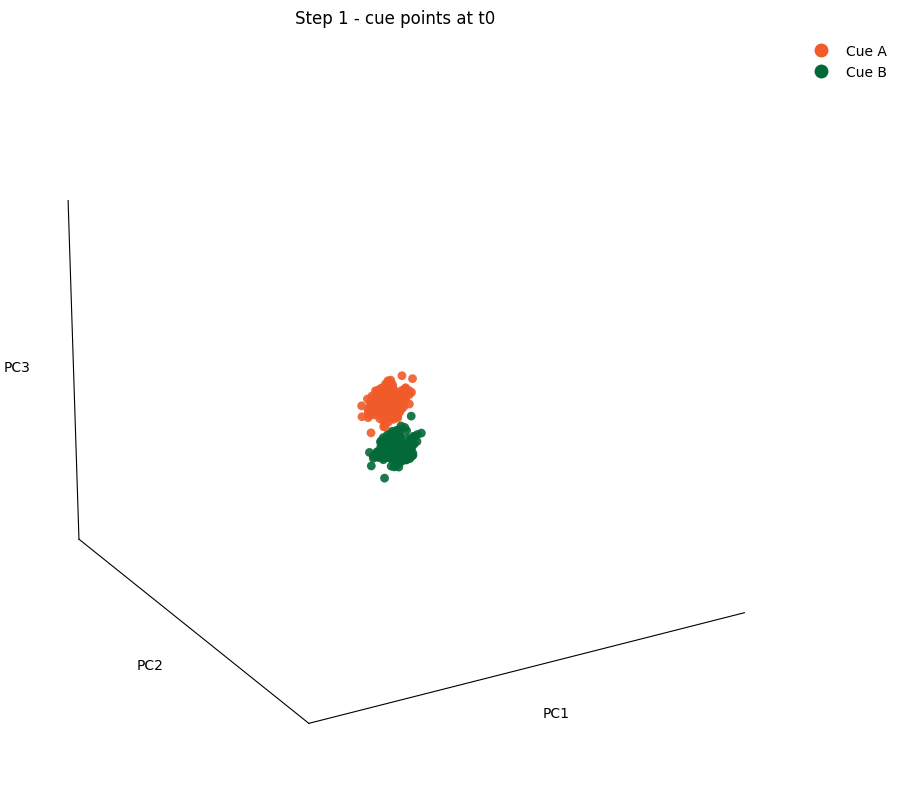

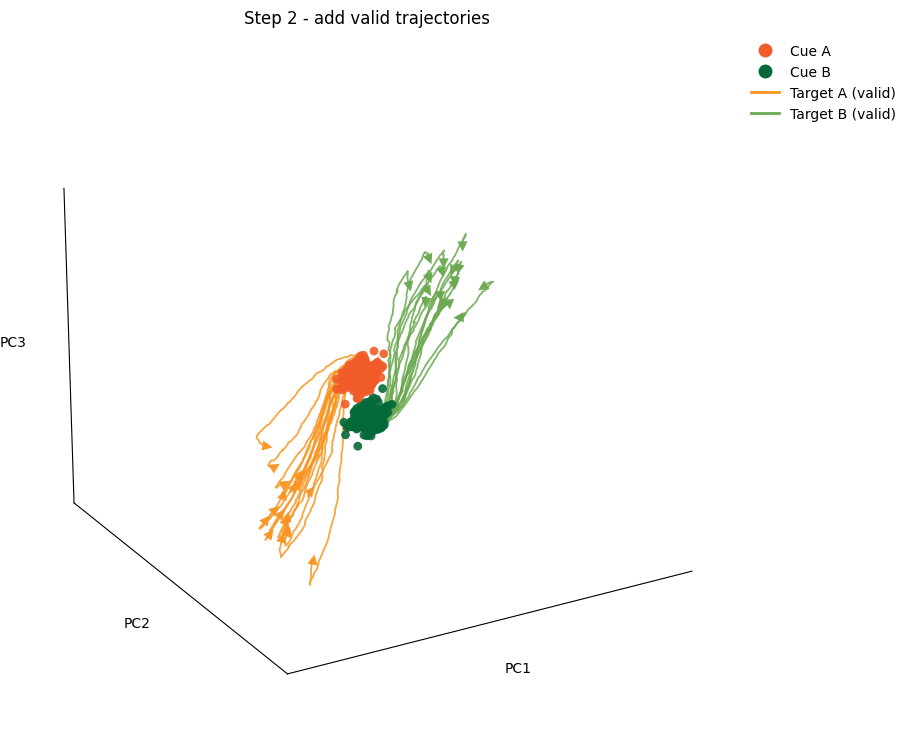

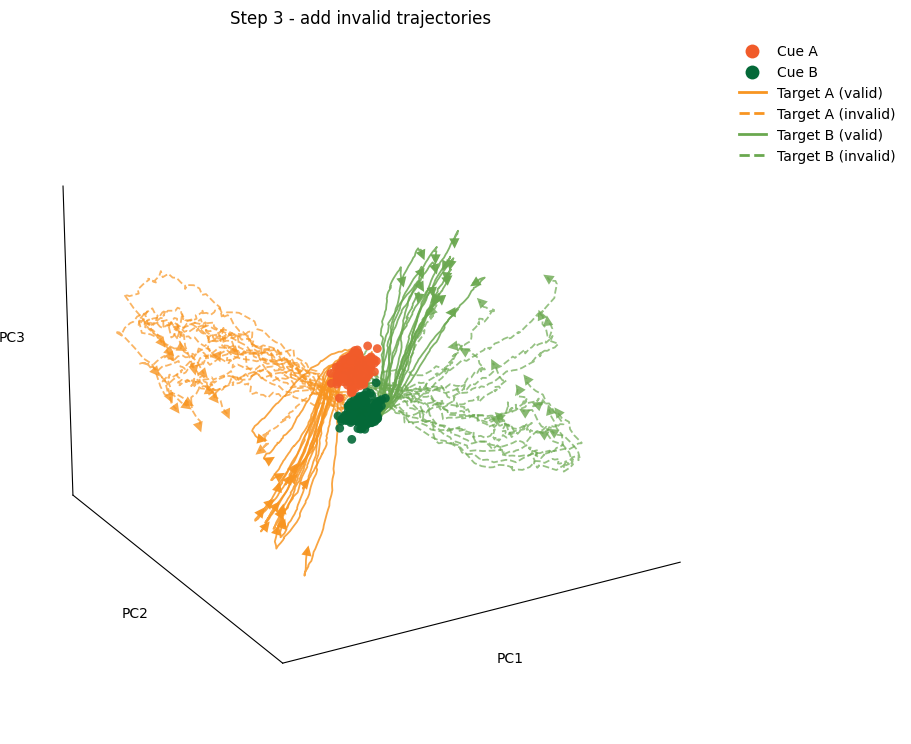

In [9]:
_DATA = {'val1': (out['val1'], target_a_color, '-'),
         'val2': (out['val2'], target_b_color, '-'),
         'inv2': (out['inv2'], target_a_color, '--'),
         'inv1': (out['inv1'], target_b_color, '--')}
_NAMES = {'val1': 'Target A (valid)', 'inv2': 'Target A (invalid)',
          'val2': 'Target B (valid)', 'inv1': 'Target B (invalid)'}
_fit = np.vstack([tr[:T] for v in _DATA.values() for tr in v[0]])
_mu = _fit.mean(0, keepdims=True); _sd = _fit.std(0, keepdims=True) + 1e-9
_pca = PCA(n_components=3).fit((_fit - _mu) / _sd)
def _proj(tr): return _pca.transform((tr[:T] - _mu) / _sd)

_rng = np.random.default_rng(0); _NS = 18
_IDS = {k: _rng.choice(len(v[0]), size=min(_NS, len(v[0])), replace=False) for k, v in _DATA.items()}
_NPT = 120
_IDP = {k: _rng.choice(len(v[0]), size=min(_NPT, len(v[0])), replace=False) for k, v in _DATA.items()}
_allP = np.vstack([_proj(_DATA[k][0][i]) for k in _DATA for i in _IDS[k]])
_pad = 0.05 * (_allP.max(0) - _allP.min(0))
_LIMS = list(zip(_allP.min(0) - _pad, _allP.max(0) + _pad))

def _emk(ax, Y, color, alpha=1.0, size=55):
    tg = Y[-1] - Y[-4]; n = np.linalg.norm(tg) + 1e-12
    if n < 1e-9: return
    tg = tg / n; e = Y[-1]; a = e + tg * 0.3; M = ax.get_proj()
    xe, ye, _ = proj3d.proj_transform(e[0], e[1], e[2], M)
    xa, ya, _ = proj3d.proj_transform(a[0], a[1], a[2], M)
    ang = np.degrees(np.arctan2(ya - ye, xa - xe)) - 90
    m = MarkerStyle('^'); m._transform = m.get_transform().rotate_deg(ang)
    ax.scatter([e[0]], [e[1]], [e[2]], s=size, marker=m, color=color,
               alpha=alpha, linewidths=0, depthshade=False, zorder=100)

def _newax():
    fig = plt.figure(figsize=(9, 8), constrained_layout=True)
    ax = fig.add_subplot(111, projection='3d'); ax.view_init(elev=22, azim=-120)
    return fig, ax

def _cuepts(ax):
    for keys, color in [(['val1', 'inv1'], cue_a_color), (['val2', 'inv2'], cue_b_color)]:
        P = np.vstack([_pca.transform((np.stack([_DATA[k][0][i][t0] for i in _IDP[k]], 0) - _mu) / _sd)
                       for k in keys])
        ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=40, color=color, edgecolor='none',
                   alpha=0.9, depthshade=False, zorder=10)

def _traj(ax, keys):
    for key in keys:
        trials, color, ls = _DATA[key]
        for i in _IDS[key]:
            Y = _proj(trials[i])
            ax.plot(Y[:, 0], Y[:, 1], Y[:, 2], color=color, ls=ls, lw=1.3,
                    alpha=0.85 if ls == '-' else 0.7)
            _emk(ax, Y, color, alpha=0.95 if ls == '-' else 0.8)

def _finish(ax, title, handles):
    ax.set_xlim(_LIMS[0]); ax.set_ylim(_LIMS[1]); ax.set_zlim(_LIMS[2]); ax.grid(False)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_pane_color((1, 1, 1, 0))
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3'); ax.set_title(title, pad=6)
    ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)

_cueh = [Line2D([0], [0], marker='o', ls='None', ms=10, mfc=cue_a_color, mec='none', label='Cue A'),
         Line2D([0], [0], marker='o', ls='None', ms=10, mfc=cue_b_color, mec='none', label='Cue B')]
_valh = _cueh + [Line2D([0], [0], color=target_a_color, lw=2, label='Target A (valid)'),
                 Line2D([0], [0], color=target_b_color, lw=2, label='Target B (valid)')]
_allh = _cueh + [Line2D([0], [0], color=_DATA[k][1], ls=_DATA[k][2], lw=2, label=_NAMES[k])
                 for k in ['val1', 'inv2', 'val2', 'inv1']]

fig, ax = _newax(); _cuepts(ax); _finish(ax, 'Step 1 - cue points at t0', _cueh)
fig.savefig(os.path.join(out_dir, 'build_step1_cuepoints.svg'), format='svg', bbox_inches='tight'); plt.show()

fig, ax = _newax(); _cuepts(ax); _traj(ax, ['val1', 'val2'])
_finish(ax, 'Step 2 - add valid trajectories', _valh)
fig.savefig(os.path.join(out_dir, 'build_step2_add_valid.svg'), format='svg', bbox_inches='tight'); plt.show()

fig, ax = _newax(); _cuepts(ax); _traj(ax, ['val1', 'val2', 'inv2', 'inv1'])
_finish(ax, 'Step 3 - add invalid trajectories', _allh)
fig.savefig(os.path.join(out_dir, 'build_step3_add_invalid.svg'), format='svg', bbox_inches='tight'); plt.show()

## 5) Trajectory rotation over time

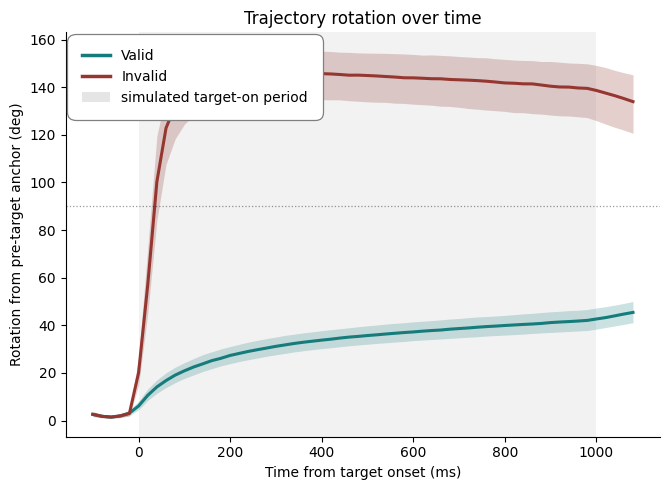

In [10]:
def plot_principal_angle_timecourse(out, seed=42):

    val1, val2 = out['val1'], out['val2']
    inv1, inv2 = out['inv1'], out['inv2']
    t0_, t1_, T_ = out['t0'], out['t1'], out['T']

    all_trials = np.stack(val1 + val2 + inv1 + inv2, axis=0)
    grand_mean = all_trials.mean(axis=(0, 1), keepdims=True)

    def trial_angle_timecourse(trials):
        angles = []
        for tr in trials:
            X = tr - grand_mean[0]
            anchor = X[:t0_].mean(axis=0)
            an = np.linalg.norm(anchor) + 1e-9
            dots = X @ anchor
            norms = np.linalg.norm(X, axis=1) + 1e-9
            cos_t = np.clip(dots / (norms * an), -1.0, 1.0)
            angles.append(np.degrees(np.arccos(cos_t)))
        return np.stack(angles, axis=0)

    ang_v = np.concatenate([
        trial_angle_timecourse(val1),
        trial_angle_timecourse(val2),
    ], axis=0)
    ang_i = np.concatenate([
        trial_angle_timecourse(inv1),
        trial_angle_timecourse(inv2),
    ], axis=0)

    med_v = np.median(ang_v, axis=0); lo_v = np.percentile(ang_v, 25, axis=0); hi_v = np.percentile(ang_v, 75, axis=0)
    med_i = np.median(ang_i, axis=0); lo_i = np.percentile(ang_i, 25, axis=0); hi_i = np.percentile(ang_i, 75, axis=0)

    times  = np.arange(T_)
    t_ms   = (times - t0_) * 20
    gray0_ms = 0
    gray1_ms = (t1_ - t0_) * 20

    ang_v_stim = ang_v[:, t0_:t1_].mean(axis=1)
    ang_i_stim = ang_i[:, t0_:t1_].mean(axis=1)

    fig, ax = plt.subplots(figsize=(6.8, 5.0))
    ax.fill_between(t_ms, lo_v, hi_v, color=valid_color,   alpha=0.22, lw=0)
    ax.fill_between(t_ms, lo_i, hi_i, color=invalid_color, alpha=0.24, lw=0)
    ax.plot(t_ms, med_v, lw=2.2, color=valid_color,   label='Valid')
    ax.plot(t_ms, med_i, lw=2.2, color=invalid_color, label='Invalid')
    ax.axvspan(gray0_ms, gray1_ms, color='grey', alpha=0.10, lw=0)
    ax.axhline(90, color='k', ls=':', alpha=0.4, lw=0.9)
    ax.set_xlabel('Time from target onset (ms)')
    ax.set_ylabel('Rotation from pre-target anchor (deg)')
    ax.set_title('Trajectory rotation over time')

    from matplotlib.patches import Patch
    handles = [
        Line2D([0], [0], color=valid_color,   lw=2.5, label='Valid'),
        Line2D([0], [0], color=invalid_color, lw=2.5, label='Invalid'),
        Patch(facecolor='grey', alpha=0.20, edgecolor='none',
              label='simulated target-on period'),
    ]
    leg = ax.legend(
        handles=handles,
        loc='upper left',
        frameon=True,
        fancybox=True,
        framealpha=1.0,
        edgecolor='0.5',
        facecolor='white',
        borderpad=0.7,
    )

    leg.get_frame().set_boxstyle('round,pad=0.4,rounding_size=0.6')
    leg.get_frame().set_linewidth(0.9)

    _despine(ax)
    fig.tight_layout()
    return fig, ax

fig, ax = plot_principal_angle_timecourse(out, seed=42)
fig.savefig(os.path.join(out_dir, 'panelC_rotation_timecourse.svg'),
            format='svg', bbox_inches='tight')
plt.show()

## 6) Per-neuron weight displacement, decomposed into null and potent subspaces

For each sampled (neuron, trial), the displacement
$\Delta W = W_\mathrm{post}^{(\mathrm{trial})} - W_\mathrm{pre}$
splits into
$\Delta W_\mathrm{null} = P_\mathrm{null}\,\Delta W$ and
$\Delta W_\mathrm{pot} = P_\mathrm{pot}\,\Delta W$.

Left: potent vs null displacement magnitude per (neuron, trial). Right: the per-neuron null fraction
$\|\Delta W_\mathrm{null}\|^2 / (\|\Delta W_\mathrm{null}\|^2 + \|\Delta W_\mathrm{pot}\|^2)$,
split by cue validity.


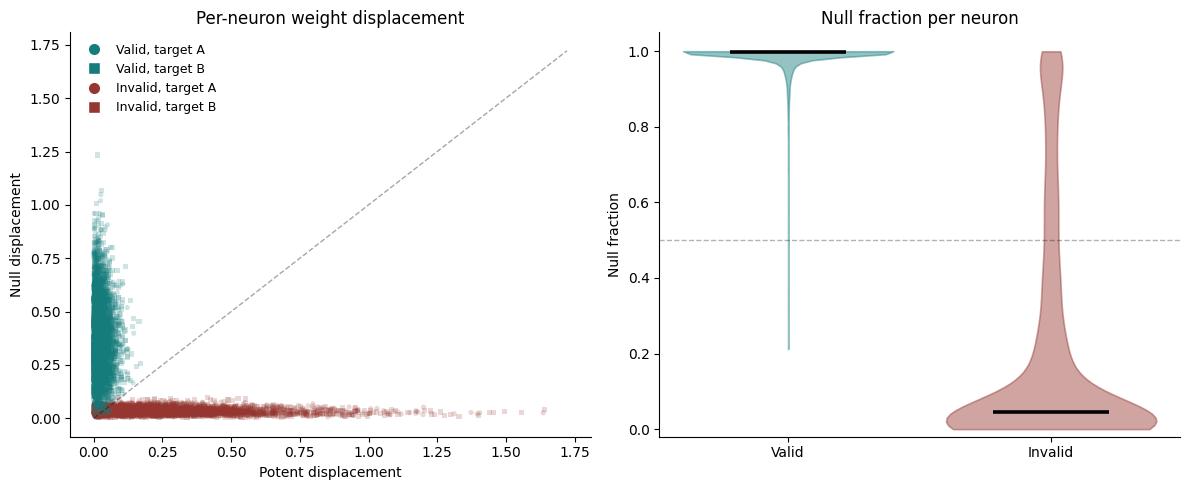

------------------------------------------------------------
Per-neuron null fraction (10,000 observations)
------------------------------------------------------------
Valid   n=5,000  median=0.9972  mean=0.9838  IQR=[0.9882, 0.9996]
Invalid n=5,000  median=0.0457  mean=0.2039  IQR=[0.0091, 0.2757]
Mann-Whitney U = 2.465e+07, p = 0.000e+00 (valid > invalid)
rank-biserial r = +0.9719
Figure saved to: /mnt/cube/jugorman/EDNpopdyn/for_github/figures/panelE_trial_level.svg


In [11]:
W_pre_E  = out["W_pre"]
W_tgt_E  = out["W_tgt_valid"]
P_null_E = out["P_null"]; P_pot_E = out["P_pot"]
per_trial_J_E = out["per_trial_J"]
signs_E  = out["signs"]

COND_META = {
    "val1": dict(valid=True,  target="A", color=COL_VALID,   marker="o"),
    "val2": dict(valid=True,  target="B", color=COL_VALID,   marker="s"),
    "inv1": dict(valid=False, target="B", color=COL_INVALID, marker="s"),
    "inv2": dict(valid=False, target="A", color=COL_INVALID, marker="o"),
}

rng_E = np.random.default_rng(42)
TRIALS_PER_COND = 25
picked = {k: rng_E.choice(len(per_trial_J_E[k]), size=TRIALS_PER_COND, replace=False)
          for k in ["val1", "val2", "inv1", "inv2"]}

records = []
for cond in ["val1", "val2", "inv1", "inv2"]:
    for t_idx in picked[cond]:
        J_trial = per_trial_J_E[cond][t_idx]
        if cond in ("val1", "val2"):
            W_post = W_tgt_E + signs_E * J_trial
        else:
            W_post = W_tgt_E + J_trial
        dW = W_post - W_pre_E
        dW_null = P_null_E @ dW
        dW_pot  = P_pot_E  @ dW
        null_mag = np.linalg.norm(dW_null, axis=1)
        pot_mag  = np.linalg.norm(dW_pot,  axis=1)
        null_ratio = null_mag ** 2 / (null_mag ** 2 + pot_mag ** 2 + 1e-12)
        records.append(dict(cond=cond, trial=int(t_idx),
                            null_mag=null_mag, pot_mag=pot_mag,
                            null_ratio=null_ratio))
assert len(records) == 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))

ax = axes[0]
order = ["inv1", "inv2", "val1", "val2"]
for cond in order:
    meta = COND_META[cond]
    for rec in records:
        if rec["cond"] != cond:
            continue
        ax.scatter(rec["pot_mag"], rec["null_mag"],
                   c=meta["color"], alpha=0.20, s=14,
                   marker=meta["marker"], edgecolor="none")

m = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, m], [0, m], "k--", alpha=0.35, lw=1)
ax.set_xlabel("Potent displacement")
ax.set_ylabel("Null displacement")
ax.set_title("Per-neuron weight displacement")

legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COL_VALID,
           markersize=9, label="Valid, target A"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=COL_VALID,
           markersize=9, label="Valid, target B"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COL_INVALID,
           markersize=9, label="Invalid, target A"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=COL_INVALID,
           markersize=9, label="Invalid, target B"),
]
ax.legend(handles=legend_elems, frameon=False, loc="upper left", fontsize=9)
_despine(ax)

valid_ratios   = np.concatenate([r["null_ratio"] for r in records
                                 if COND_META[r["cond"]]["valid"]])
invalid_ratios = np.concatenate([r["null_ratio"] for r in records
                                 if not COND_META[r["cond"]]["valid"]])

ax = axes[1]
parts = ax.violinplot([valid_ratios, invalid_ratios],
                      positions=[0, 1], widths=0.8,
                      showmeans=False, showmedians=False, showextrema=False)
for body, c in zip(parts["bodies"], [COL_VALID, COL_INVALID]):
    body.set_facecolor(c); body.set_edgecolor(c)
    body.set_alpha(0.45); body.set_linewidth(1.2)

for x_pos, vals in [(0, valid_ratios), (1, invalid_ratios)]:
    med = float(np.median(vals))
    ax.hlines(med, x_pos - 0.22, x_pos + 0.22,
              color="k", linewidth=2.6, zorder=5)

ax.axhline(0.5, color="k", ls="--", alpha=0.3, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Valid", "Invalid"])
ax.set_ylabel("Null fraction")
ax.set_title("Null fraction per neuron")
ax.set_ylim(-0.02, 1.05)
_despine(ax)

fig.tight_layout()

panelE_svg = os.path.join(out_dir, "panelE_trial_level.svg")
panelE_png = os.path.join(out_dir, "panelE_trial_level.png")
fig.savefig(panelE_svg, format="svg", bbox_inches="tight")
fig.savefig(panelE_png, format="png", dpi=120, bbox_inches="tight")
plt.show()

U_rat, p_rat = mannwhitneyu(valid_ratios, invalid_ratios, alternative="greater")
nV_E, nI_E = len(valid_ratios), len(invalid_ratios)
r_rb_E = 1.0 - 2.0 * U_rat / (nV_E * nI_E)
r_rb_E = -r_rb_E

print("-" * 60)
print(f"Per-neuron null fraction (10,000 observations)")
print("-" * 60)
print(f"Valid   n={nV_E:,}  median={np.median(valid_ratios):.4f}  "
      f"mean={valid_ratios.mean():.4f}  IQR=[{np.percentile(valid_ratios,25):.4f}, "
      f"{np.percentile(valid_ratios,75):.4f}]")
print(f"Invalid n={nI_E:,}  median={np.median(invalid_ratios):.4f}  "
      f"mean={invalid_ratios.mean():.4f}  IQR=[{np.percentile(invalid_ratios,25):.4f}, "
      f"{np.percentile(invalid_ratios,75):.4f}]")
print(f"Mann-Whitney U = {U_rat:.3e}, p = {p_rat:.3e} (valid > invalid)")
print(f"rank-biserial r = {r_rb_E:+.4f}")
print(f"Figure saved to: {panelE_svg}")


## 7) Potent vs null projected trial scatter

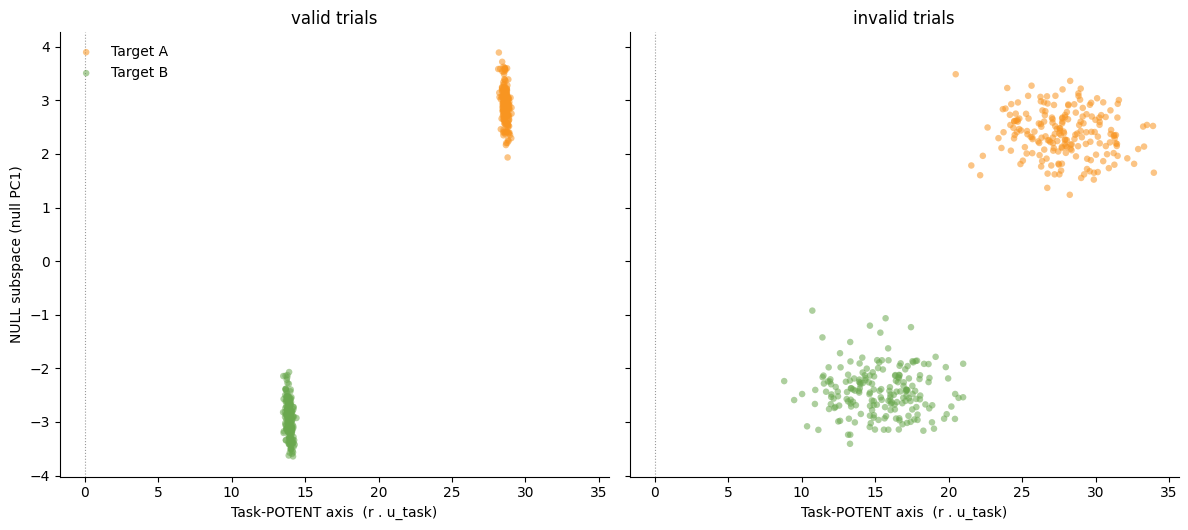

In [12]:
_u = out['u_task']; _u = _u / np.linalg.norm(_u)
_v1, _v2 = out['val1'], out['val2']
_i1, _i2 = out['inv1'], out['inv2']

_WvA = np.stack([tr[t0:t1] for tr in _v1], 0); _WvB = np.stack([tr[t0:t1] for tr in _v2], 0)
_WiA = np.stack([tr[t0:t1] for tr in _i2], 0); _WiB = np.stack([tr[t0:t1] for tr in _i1], 0)

def _pot_null(W):
    p = W @ _u
    return p, W - p[..., None] * _u[None, None, :]

_all = np.vstack([_WvA, _WvB, _WiA, _WiB])
_, _null_all = _pot_null(_all)
_flat = _null_all.reshape(-1, _all.shape[-1])
_nmu = _flat.mean(0, keepdims=True)
_npca = PCA(n_components=2).fit(_flat - _nmu)

def _scores(W):
    p, nu = _pot_null(W)
    return p.mean(1), _npca.transform(nu.mean(1) - _nmu)[:, 0]

_groups = {'A': target_a_color, 'B': target_b_color}
_data = {'valid':   {'A': _WvA, 'B': _WvB}, 'invalid': {'A': _WiA, 'B': _WiB}}

_rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), sharex=True, sharey=True)
for ax, name in zip(axes, ['valid', 'invalid']):
    for tgt, col in _groups.items():
        x, y = _scores(_data[name][tgt])
        ii = _rng.choice(len(x), size=min(200, len(x)), replace=False)
        ax.scatter(x[ii], y[ii], s=22, color=col, alpha=0.55, edgecolor='none',
                   label=f'Target {tgt}')
    ax.axvline(0, color='0.6', lw=0.8, ls=':')
    ax.set_title(f'{name} trials', fontsize=12)
    ax.set_xlabel('Task-POTENT axis  (r . u_task)')
axes[0].set_ylabel('NULL subspace (null PC1)')
axes[0].legend(frameon=False, loc='upper left')
fig.tight_layout()
fig.savefig(os.path.join(out_dir, 'potent_vs_null_scatter.svg'), format='svg', bbox_inches='tight')
plt.show()

## 8) Single-neuron vs population trajectory cosine similarity

/tmp/ipykernel_1287737/2842005194.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1287737/2842005194.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


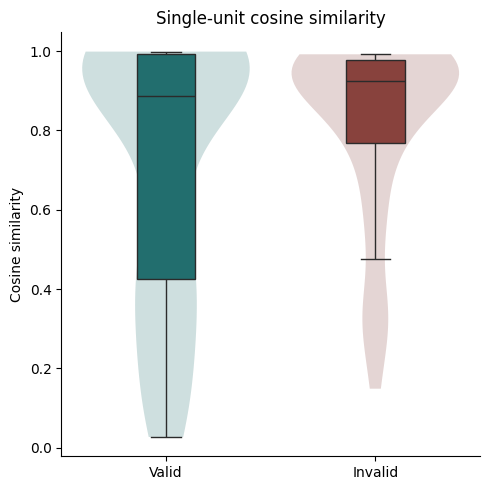

/tmp/ipykernel_1287737/2842005194.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1287737/2842005194.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


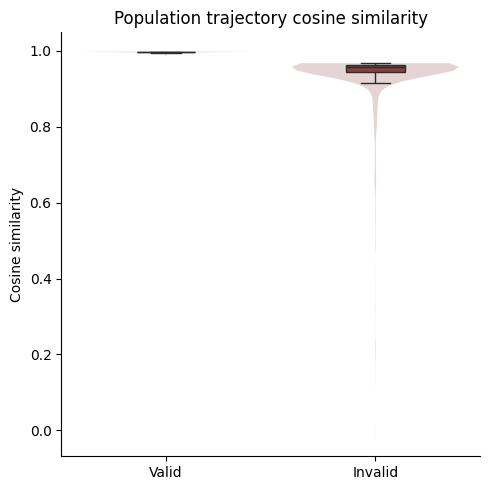


Single-unit:
  mean valid   = +0.7058
  mean invalid = +0.8171
  Delta V-I    = -0.1113, 95% CI (-0.17329206931903243, -0.055063058459550514)
  Wilcoxon W   = 3029.0, p(invalid>valid) = 4.156e-02
  n neurons    = 100

Population:
  mean valid   = +0.9967
  mean invalid = +0.9367
  Delta V-I    = +0.0600, 95% CI (0.05541051593161122, 0.06495950192174309)
  Mann-Whitney p(valid>invalid) = 0.000e+00
  rank-biserial r = +1.000
  n (pooled pairs) valid = 1200, invalid = 1200


In [13]:
val1 = out['val1']; val2 = out['val2']
inv1 = out['inv1']; inv2 = out['inv2']

def population_metrics(val1, val2, inv1, inv2, t0, t1, mode='within'):

    from sklearn.decomposition import PCA as _PCA
    _KPOP = 3
    _pool = np.vstack([np.vstack([tr[t0:t1] for tr in L]) for L in (val1, val2, inv1, inv2)])
    _pmu = _pool.mean(0, keepdims=True)
    _ppca = _PCA(n_components=_KPOP).fit(_pool - _pmu)
    def _ptraj(trials):
        return np.stack([_ppca.transform(tr[t0:t1] - _pmu).reshape(-1) for tr in trials], axis=0)
    V1 = _ptraj(val1)
    V2 = _ptraj(val2)
    I1 = _ptraj(inv1)
    I2 = _ptraj(inv2)
    if mode == 'within':
        m_val = np.concatenate([_offdiag_means(cosine_similarity(V1)),
                                _offdiag_means(cosine_similarity(V2))])
        m_inv = np.concatenate([_offdiag_means(cosine_similarity(I1)),
                                _offdiag_means(cosine_similarity(I2))])
    else:
        V = np.vstack([V1, V2]); I = np.vstack([I1, I2])
        m_val = _offdiag_means(cosine_similarity(V))
        m_inv = _offdiag_means(cosine_similarity(I))
    m_val = m_val[np.isfinite(m_val)]
    m_inv = m_inv[np.isfinite(m_inv)]
    U, p = mannwhitneyu(m_val, m_inv, alternative='greater')
    nV, nI = len(m_val), len(m_inv)
    r_rb = 1.0 - (2.0 * U) / (nV * nI)
    r_rb = -r_rb
    delta = float(np.mean(m_val) - np.mean(m_inv))

    rng = np.random.default_rng(0)
    boots = np.empty(2000)
    for b in range(2000):
        boots[b] = np.mean(rng.choice(m_val, nV)) - np.mean(rng.choice(m_inv, nI))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return m_val, m_inv, float(p), float(r_rb), (delta, float(lo), float(hi))
def _per_neuron_mean_pairwise_cosine(trials, n_idx, t0_, t1_):

    win = np.stack([tr[t0_:t1_, n_idx] for tr in trials], axis=0)

    win = win - win.mean(axis=1, keepdims=True)
    norms = np.linalg.norm(win, axis=1, keepdims=True) + 1e-12
    win_n = win / norms
    C = win_n @ win_n.T
    mask = ~np.eye(C.shape[0], dtype=bool)
    return float(C[mask].mean())
def single_unit_metrics(val1, val2, inv1, inv2, t0, t1):

    N = val1[0].shape[1]
    unit_val = np.empty(N); unit_inv = np.empty(N)
    for n in range(N):
        cvA = _per_neuron_mean_pairwise_cosine(val1, n, t0, t1)
        cvB = _per_neuron_mean_pairwise_cosine(val2, n, t0, t1)
        ciA = _per_neuron_mean_pairwise_cosine(inv1, n, t0, t1)
        ciB = _per_neuron_mean_pairwise_cosine(inv2, n, t0, t1)
        unit_val[n] = 0.5 * (cvA + cvB)
        unit_inv[n] = 0.5 * (ciA + ciB)
    diff = unit_val - unit_inv

    res = wilcoxon(unit_inv - unit_val, alternative='greater')
    W = float(res.statistic); p_wil = float(res.pvalue)
    frac = float(np.mean(unit_inv > unit_val))

    rng = np.random.default_rng(0)
    dbar = float(np.mean(unit_inv - unit_val))
    boots = np.array([np.mean(rng.choice(unit_inv - unit_val, N)) for _ in range(2000)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    dbar_ci_inv_minus_val = (dbar, float(lo), float(hi))
    return unit_val, unit_inv, W, p_wil, frac, dbar_ci_inv_minus_val

def plot_three_panels_summary_noboot(
    val1, val2, inv1, inv2, t0, t1,
    population_mode='within',
    figsize_box=(5, 5),
    figsize_bar=(6.0, 4.6),
    out_dir=None,
    file_prefix='cosine_summary'
):
    import os
    COL_VALID = pal.valid
    COL_INVALID = pal.invalid
    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)
    def _despine(ax):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    def _violin_box(ax, df):

        _n0 = len(ax.collections)
        sns.violinplot(
            data=df, x='Condition', y='Cosine Similarity', order=['Valid', 'Invalid'],
            palette={'Valid': COL_VALID, 'Invalid': COL_INVALID},
            inner=None, cut=0, linewidth=0, ax=ax
        )
        for coll in ax.collections[_n0:]:
            coll.set_alpha(0.22); coll.set_edgecolor('none'); coll.set_zorder(0)

        sns.boxplot(
            data=df, x='Condition', y='Cosine Similarity', order=['Valid', 'Invalid'],
            palette={'Valid': COL_VALID, 'Invalid': COL_INVALID},
            showfliers=False, width=0.28, ax=ax, boxprops=dict(zorder=2)
        )

    unit_val, unit_inv, W, p_wil, frac, dbar_ci_inv_minus_val = single_unit_metrics(
        val1, val2, inv1, inv2, t0, t1
    )
    dbar_u_i_minus_v, lo_u_i_minus_v, hi_u_i_minus_v = dbar_ci_inv_minus_val
    dbar_u = -dbar_u_i_minus_v
    lo_u = -hi_u_i_minus_v
    hi_u = -lo_u_i_minus_v

    m_val, m_inv, p_mwu, r_rb, dbar_ci_pop = population_metrics(
        val1, val2, inv1, inv2, t0, t1, mode=population_mode
    )
    dbar_p, lo_p, hi_p = dbar_ci_pop
    unit_val = np.asarray(unit_val, dtype=float); unit_val = unit_val[np.isfinite(unit_val)]
    unit_inv = np.asarray(unit_inv, dtype=float); unit_inv = unit_inv[np.isfinite(unit_inv)]
    m_val = np.asarray(m_val, dtype=float);       m_val = m_val[np.isfinite(m_val)]
    m_inv = np.asarray(m_inv, dtype=float);       m_inv = m_inv[np.isfinite(m_inv)]
    pop_val_plot = np.array([np.mean(m_val)]) if len(m_val) else np.array([])
    pop_inv_plot = np.array([np.mean(m_inv)]) if len(m_inv) else np.array([])

    plot_df_unit = pd.DataFrame({
        'Condition': ['Valid'] * len(unit_val) + ['Invalid'] * len(unit_inv),
        'Cosine Similarity': np.concatenate([unit_val, unit_inv])
    })
    fig1, ax1 = plt.subplots(figsize=figsize_box)
    _violin_box(ax1, plot_df_unit)
    ax1.set_title('Single-unit cosine similarity')
    ax1.set_ylabel('Cosine similarity'); ax1.set_xlabel('')
    sns.despine(ax=ax1)
    fig1.tight_layout()
    if out_dir is not None:
        fig1.savefig(os.path.join(out_dir, f'{file_prefix}_single_unit_boxplot.svg'),
                     format='svg', bbox_inches='tight')
    plt.show()

    plot_df_pop = pd.DataFrame({
        'Condition': ['Valid'] * len(m_val) + ['Invalid'] * len(m_inv),
        'Cosine Similarity': np.concatenate([m_val, m_inv])
    })
    fig2, ax2 = plt.subplots(figsize=figsize_box)
    _violin_box(ax2, plot_df_pop)
    ax2.set_title('Population trajectory cosine similarity')
    ax2.set_ylabel('Cosine similarity'); ax2.set_xlabel('')
    sns.despine(ax=ax2)
    fig2.tight_layout()
    if out_dir is not None:
        fig2.savefig(os.path.join(out_dir, f'{file_prefix}_population_boxplot.svg'),
                     format='svg', bbox_inches='tight')
    plt.show()

    return {
        'single_unit': {
            'n_valid': int(len(unit_val)),
            'n_invalid': int(len(unit_inv)),
            'mean_valid': float(np.mean(unit_val)) if len(unit_val) else np.nan,
            'mean_invalid': float(np.mean(unit_inv)) if len(unit_inv) else np.nan,
            'delta_v_minus_i': float(dbar_u),
            'ci': (float(lo_u), float(hi_u)),
            'wilcoxon_W': float(W),
            'wilcoxon_p_inv_gt_val': float(p_wil),
            'frac_inv_gt_val': float(frac),
        },
        'population': {
            'mode': population_mode,
            'n_valid_raw': int(len(m_val)),
            'n_invalid_raw': int(len(m_inv)),
            'n_valid_plot': int(len(pop_val_plot)),
            'n_invalid_plot': int(len(pop_inv_plot)),
            'mean_valid': float(np.mean(m_val)) if len(m_val) else np.nan,
            'mean_invalid': float(np.mean(m_inv)) if len(m_inv) else np.nan,
            'delta_v_minus_i': float(dbar_p),
            'ci': (float(lo_p), float(hi_p)),
            'mannwhitney_p_val_gt_inv': float(p_mwu),
            'rank_biserial_r': float(r_rb),
        },
    }
summary = plot_three_panels_summary_noboot(
    val1, val2, inv1, inv2, t0, t1,
    population_mode='within',
    out_dir=out_dir,
    file_prefix='cosine_summary'
)
print()
print('Single-unit:')
print(f"  mean valid   = {summary['single_unit']['mean_valid']:+.4f}")
print(f"  mean invalid = {summary['single_unit']['mean_invalid']:+.4f}")
print(f"  Delta V-I    = {summary['single_unit']['delta_v_minus_i']:+.4f}, 95% CI {summary['single_unit']['ci']}")
print(f"  Wilcoxon W   = {summary['single_unit']['wilcoxon_W']:.1f}, p(invalid>valid) = {summary['single_unit']['wilcoxon_p_inv_gt_val']:.3e}")
print(f"  n neurons    = {summary['single_unit']['n_valid']}")
print()
print('Population:')
print(f"  mean valid   = {summary['population']['mean_valid']:+.4f}")
print(f"  mean invalid = {summary['population']['mean_invalid']:+.4f}")
print(f"  Delta V-I    = {summary['population']['delta_v_minus_i']:+.4f}, 95% CI {summary['population']['ci']}")
print(f"  Mann-Whitney p(valid>invalid) = {summary['population']['mannwhitney_p_val_gt_inv']:.3e}")
print(f"  rank-biserial r = {summary['population']['rank_biserial_r']:+.3f}")
print(f"  n (pooled pairs) valid = {summary['population']['n_valid_raw']}, invalid = {summary['population']['n_invalid_raw']}")

## 9) Combined delta bar plot

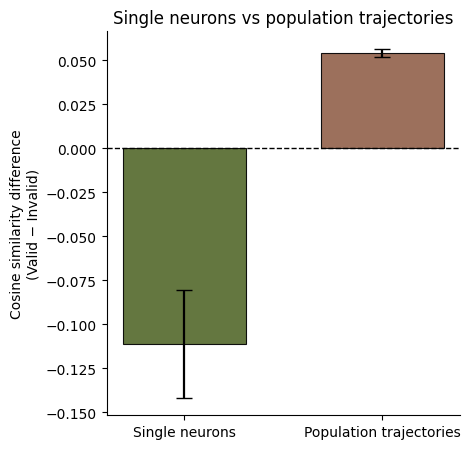


Single-neuron paired delta (Valid - Invalid)
n neurons = 100
mean = -0.111281,   SEM = 0.030525
one-sample t-test vs 0: t = -3.6456, p = 4.2737e-04

Population paired delta (Valid - Invalid, target-matched)
n pairs = 1200
mean = +0.054076,   SEM = 0.002390
one-sample t-test vs 0: t = 22.6264, p = 1.1204e-94


In [14]:
COL_DELTA_NEG = pal.delta_neg
COL_DELTA_POS = pal.delta_pos
COL_DELTA_NS  = pal.delta_ns

def _neuron_pairwise_cosine(trials, n, t0_, t1_):
    W   = np.stack([tr[t0_:t1_, n] for tr in trials], axis=0)
    W   = W - W.mean(axis=1, keepdims=True)
    nrm = np.linalg.norm(W, axis=1, keepdims=True) + 1e-12
    Wn  = W / nrm
    C   = Wn @ Wn.T
    mask = ~np.eye(C.shape[0], dtype=bool)
    return float(C[mask].mean())

N = val1[0].shape[1]
valid_vals_sn   = np.empty(N)
invalid_vals_sn = np.empty(N)
for n in range(N):
    cvA = _neuron_pairwise_cosine(val1, n, t0, t1)
    cvB = _neuron_pairwise_cosine(val2, n, t0, t1)
    ciA = _neuron_pairwise_cosine(inv1, n, t0, t1)
    ciB = _neuron_pairwise_cosine(inv2, n, t0, t1)
    valid_vals_sn[n]   = 0.5 * (cvA + cvB)
    invalid_vals_sn[n] = 0.5 * (ciA + ciB)


def _offdiag_row_means(S):
    n = S.shape[0]
    out = np.empty(n)
    for i in range(n):
        out[i] = (S[i].sum() - S[i, i]) / max(n - 1, 1)
    return out

_KPOP = 10
_pool_pop = np.vstack([np.vstack([tr[t0:t1] for tr in L]) for L in (val1, val2, inv1, inv2)])
_popmu = _pool_pop.mean(0, keepdims=True)
_poppca = _PCA(n_components=_KPOP).fit(_pool_pop - _popmu)
def _within_group_pop(trials, t0_, t1_):

    X  = np.stack([_poppca.transform(tr[t0_:t1_] - _popmu).reshape(-1) for tr in trials], axis=0)
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    S  = Xn @ Xn.T
    return _offdiag_row_means(S)

strata_valid = {
    'target_A': _within_group_pop(val1, t0, t1),
    'target_B': _within_group_pop(val2, t0, t1),
}
strata_invalid = {
    'target_A': _within_group_pop(inv2, t0, t1),
    'target_B': _within_group_pop(inv1, t0, t1),
}
pop_valid_strata   = np.concatenate(list(strata_valid.values()))
pop_invalid_strata = np.concatenate(list(strata_invalid.values()))

def _choose_color(diffs, alpha=0.05):
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    if len(diffs) < 2:
        return COL_DELTA_NS, np.nan, np.nan, np.nan
    mean = float(np.mean(diffs))
    res  = ttest_1samp(diffs, 0.0)
    t_stat = float(res.statistic)
    p_val  = float(res.pvalue)
    if p_val >= alpha:
        color = COL_DELTA_NS
    elif mean < 0:
        color = COL_DELTA_NEG
    else:
        color = COL_DELTA_POS
    return color, mean, t_stat, p_val

def _sem(x):

    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=1) / np.sqrt(len(x)))

diff_single = valid_vals_sn - invalid_vals_sn
diff_single = diff_single[np.isfinite(diff_single)]
c_s, m_s, t_s, p_s = _choose_color(diff_single)
sem_s = _sem(diff_single)

min_n = min(len(pop_valid_strata), len(pop_invalid_strata))
rng    = np.random.default_rng(0)
v_perm = rng.permutation(pop_valid_strata)[:min_n]
i_perm = rng.permutation(pop_invalid_strata)[:min_n]
diff_pop = v_perm - i_perm
c_p, m_p, t_p, p_p = _choose_color(diff_pop)
sem_p = _sem(diff_pop)

def plot_combined_delta_bar(
    labels, means, sems, colors, pvals=None,
    figsize=(4.8, 4.6), out_path=None,
):
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(labels))
    width = 0.62
    for i, (m, sem, c) in enumerate(zip(means, sems, colors)):
        ax.bar(x[i], m, width=width, color=c, alpha=0.92,
               edgecolor='k', linewidth=0.8)
        ax.errorbar(x[i], m, yerr=sem, fmt='none', capsize=6,
                    lw=1.6, color='k', zorder=3)
    ax.axhline(0, color='black', linewidth=1, ls='--')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('Cosine similarity difference\n(Valid \u2212 Invalid)')
    ax.set_title('Single neurons vs population trajectories')
    sns.despine(ax=ax)
    if pvals is not None:
        y_offsets = (np.array([abs(s) for s in sems])
                     + 0.02 * (abs(max(means, key=abs)) + 1e-9))
        for i, (m, p, off) in enumerate(zip(means, pvals, y_offsets)):
            y = m + off if m >= 0 else m - off
            va = 'bottom' if m >= 0 else 'top'
            s = 'p < 1e-3' if p < 1e-3 else f'p = {p:.2g}'
            ax.text(x[i], y, s, ha='center', va=va, fontsize=9)
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    return fig, ax

plot_combined_delta_bar(
    labels=['Single neurons', 'Population trajectories'],
    means=[m_s, m_p],
    sems=[sem_s, sem_p],
    colors=[c_s, c_p],
    pvals=None,
    out_path=os.path.join(out_dir, 'combined_delta_bar.svg'),
)

print()
print('=' * 64)
print('Single-neuron paired delta (Valid - Invalid)')
print('=' * 64)
print(f'n neurons = {len(diff_single)}')
print(f'mean = {m_s:+.6f},   SEM = {sem_s:.6f}')
print(f'one-sample t-test vs 0: t = {t_s:.4f}, p = {p_s:.4e}')

print()
print('=' * 64)
print('Population paired delta (Valid - Invalid, target-matched)')
print('=' * 64)
print(f'n pairs = {len(diff_pop)}')
print(f'mean = {m_p:+.6f},   SEM = {sem_p:.6f}')
print(f'one-sample t-test vs 0: t = {t_p:.4f}, p = {p_p:.4e}')

## 10) Single-neuron vs population readout 

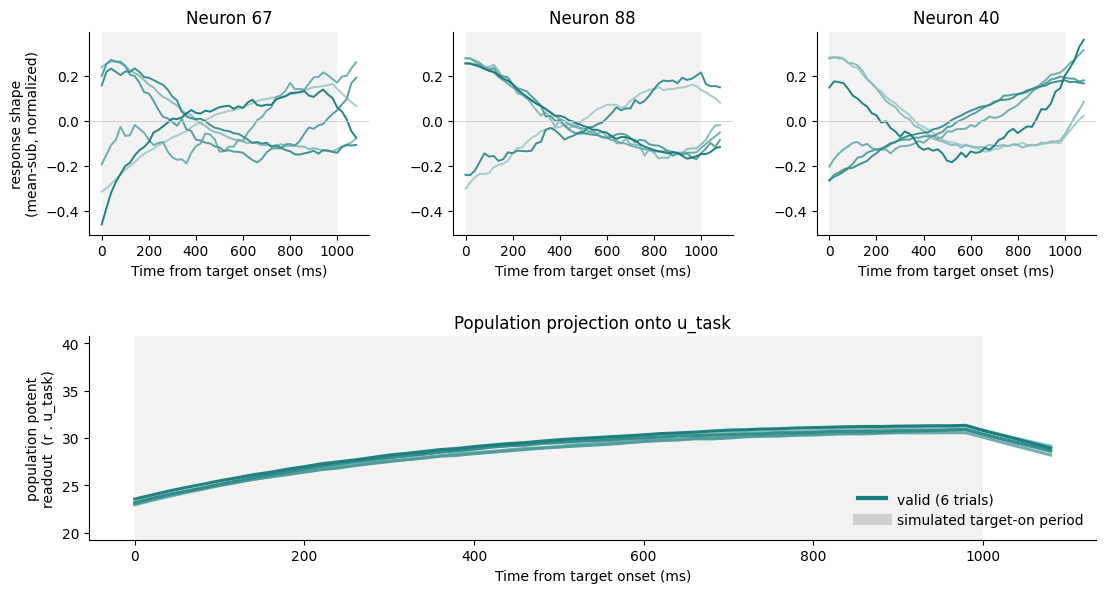

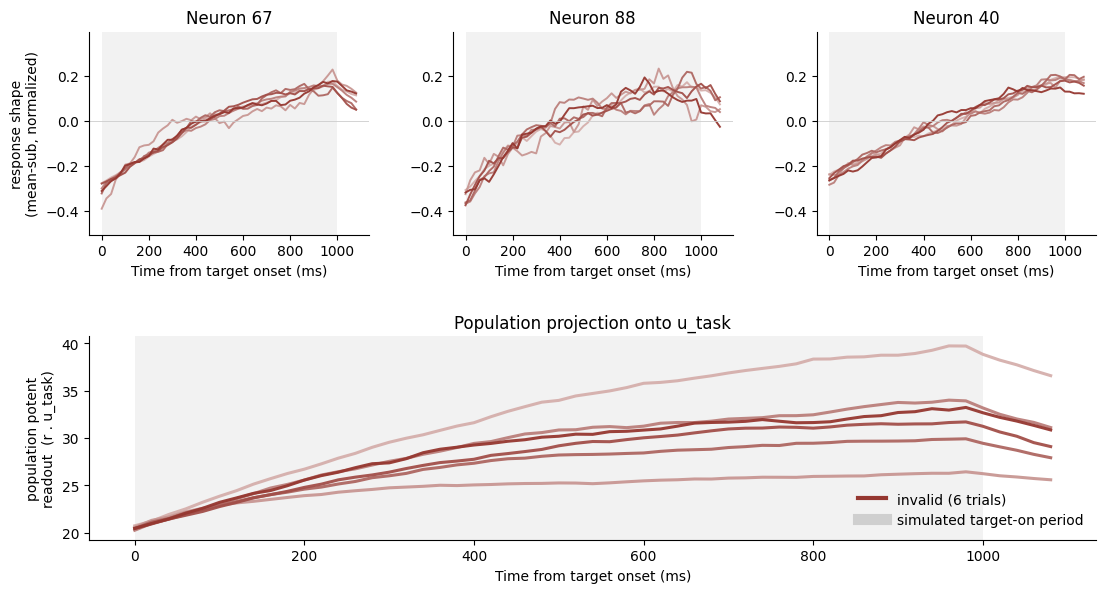

In [15]:
_u = out['u_task']; _u = _u / np.linalg.norm(_u)
_valid = out['val1']; _invalid = out['inv2']
_TT_ms   = (np.arange(t0, T) - t0) * 20
_GRAY1   = (t1 - t0) * 20

def _shades(base_hex, n, lightest=0.6):
    base = np.array(mcolors.to_rgb(base_hex)); white = np.ones(3)
    return [tuple(base * (1 - f) + white * f) for f in np.linspace(lightest, 0.0, n)]

def _shape_cos(trials, nshow=200):
    W = np.stack([tr[t0:T] for tr in trials[:nshow]], 0)
    cs = []
    for nrn in range(W.shape[2]):
        X = W[:, :, nrn]; X = X - X.mean(1, keepdims=True)
        Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
        C = Xn @ Xn.T; iu = np.triu_indices(X.shape[0], 1)
        cs.append(C[iu].mean())
    return np.array(cs)

_cV = _shape_cos(_valid); _cI = _shape_cos(_invalid)
_amp = np.stack([tr[t0:T] for tr in _valid[:200]], 0).std(0).mean(0)
_sel = np.argsort((_cI - _cV) * (_amp > np.percentile(_amp, 40)))[-3:][::-1]

_rng = np.random.default_rng(3); _NTR = 6
_vids = _rng.choice(len(_valid), size=_NTR, replace=False)
_iids = _rng.choice(len(_invalid), size=_NTR, replace=False)

def _ns(tr, nrn):
    x = tr[t0:T, nrn].astype(float); x = x - x.mean()
    return x / (np.linalg.norm(x) + 1e-9)

_sh = []; _po = []
for _trials, _ids in [(_valid, _vids), (_invalid, _iids)]:
    for i in _ids:
        _po.append(_trials[i][t0:T] @ _u)
        for nrn in _sel:
            _sh.append(_ns(_trials[i], nrn))
_sh = np.concatenate(_sh); _po = np.concatenate(_po)
_shlim = (_sh.min() * 1.1, _sh.max() * 1.1); _polim = (_po.min() - 1, _po.max() + 1)

def _make(trials, ids, color, label, fname):
    cols = _shades(color, _NTR)
    fig = plt.figure(figsize=(13, 6.6))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.5, wspace=0.3)
    for c, nrn in enumerate(_sel):
        ax = fig.add_subplot(gs[0, c])
        ax.axvspan(0, _GRAY1, color='grey', alpha=0.10, lw=0)
        for ti, i in enumerate(ids):
            ax.plot(_TT_ms, _ns(trials[i], nrn), color=cols[ti], lw=1.4, alpha=0.95)
        ax.axhline(0, color='0.8', lw=0.6); ax.set_ylim(_shlim)
        ax.set_title('Neuron %d' % nrn); ax.set_xlabel('Time from target onset (ms)')
        if c == 0:
            ax.set_ylabel('response shape\n(mean-sub, normalized)')
    axb = fig.add_subplot(gs[1, :])
    axb.axvspan(0, _GRAY1, color='grey', alpha=0.10, lw=0)
    for ti, i in enumerate(ids):
        axb.plot(_TT_ms, trials[i][t0:T] @ _u, color=cols[ti], lw=2.2, alpha=0.95)
    axb.set_ylim(_polim)
    axb.set_title('Population projection onto u_task')
    axb.set_xlabel('Time from target onset (ms)')
    axb.set_ylabel('population potent\nreadout  (r . u_task)')
    axb.legend(handles=[Line2D([0], [0], color=color, lw=3, label=label.lower() + ' (6 trials)'),
                        Line2D([0], [0], color='grey', alpha=0.3, lw=8,
                               label='simulated target-on period')],
               frameon=False, loc='lower right')
    fig.savefig(os.path.join(out_dir, fname), format='svg', bbox_inches='tight')
    plt.show()

_make(_valid, _vids, valid_color, 'VALID', 'single_to_population_VALID.svg')
_make(_invalid, _iids, invalid_color, 'INVALID', 'single_to_population_INVALID.svg')

## 11) Save stats

In [16]:
csv_dir  = f'{STATS_CSV_DIR}'
os.makedirs(csv_dir, exist_ok=True)
csv_path = os.path.join(csv_dir, '3.1_popgeom_model_stats.csv')
rows = []

_uv2, _ui2, _Ww, _pw, _frac_w, _ = single_unit_metrics(val1, val2, inv1, inv2, t0, t1)
_res_wil = wilcoxon(_ui2 - _uv2, alternative='greater')
rows.append(dict(
    analysis='single_unit_cosine', test='wilcoxon_signed_rank',
    alternative='invalid > valid', group_a='invalid', group_b='valid',
    n_a=int(len(_ui2)), n_b=int(len(_uv2)),
    mean_a=float(np.mean(_ui2)), mean_b=float(np.mean(_uv2)),
    median_a=float(np.median(_ui2)), median_b=float(np.median(_uv2)),
    delta_a_minus_b=float(np.mean(_ui2-_uv2)),
    statistic=float(_res_wil.statistic), p_value=float(_res_wil.pvalue),
    frac_a_gt_b=float(np.mean(_ui2 > _uv2)),
    note='per-neuron mean pairwise within-target cosine; Wilcoxon tests invalid>valid',
))

_mv2, _mi2, _pmw2, _rrb2, _ = population_metrics(val1, val2, inv1, inv2, t0, t1, mode='within')
_mv2 = _mv2[np.isfinite(_mv2)]; _mi2 = _mi2[np.isfinite(_mi2)]
rows.append(dict(
    analysis='population_cosine', test='mann_whitney_u',
    alternative='valid > invalid', group_a='valid', group_b='invalid',
    n_a=int(len(_mv2)), n_b=int(len(_mi2)),
    mean_a=float(np.mean(_mv2)), mean_b=float(np.mean(_mi2)),
    median_a=float(np.median(_mv2)), median_b=float(np.median(_mi2)),
    delta_a_minus_b=float(np.mean(_mv2)-np.mean(_mi2)),
    statistic=float(mannwhitneyu(_mv2, _mi2, alternative='greater').statistic),
    p_value=float(_pmw2),
    frac_a_gt_b=float(np.mean(_mv2 > np.median(_mi2))),
    note='per-trial pairwise within-target population TRAJECTORY cosine in top-10 PCA space; MWU tests valid>invalid',
))

_d27 = valid_vals_sn - invalid_vals_sn; _d27 = _d27[np.isfinite(_d27)]
_t_sn, _p_sn = ttest_1samp(_d27, 0.0)
rows.append(dict(
    analysis='single_neuron_delta_V_minus_I', test='one_sample_t_test',
    alternative='two-sided', group_a='valid', group_b='invalid',
    n_a=int(len(valid_vals_sn)), n_b=int(len(invalid_vals_sn)),
    mean_a=float(np.mean(valid_vals_sn)), mean_b=float(np.mean(invalid_vals_sn)),
    median_a=float(np.median(valid_vals_sn)), median_b=float(np.median(invalid_vals_sn)),
    delta_a_minus_b=float(np.mean(_d27)),
    statistic=float(_t_sn), p_value=float(_p_sn),
    frac_a_gt_b=float(np.mean(valid_vals_sn > invalid_vals_sn)),
    note='cell-27 single-neuron cosine V-I; one-sample t vs 0',
))

_dp27 = v_perm - i_perm; _dp27 = _dp27[np.isfinite(_dp27)]
_t_pop, _p_pop = ttest_1samp(_dp27, 0.0)
rows.append(dict(
    analysis='population_delta_V_minus_I', test='one_sample_t_test',
    alternative='two-sided', group_a='valid', group_b='invalid',
    n_a=int(len(v_perm)), n_b=int(len(i_perm)),
    mean_a=float(np.mean(v_perm)), mean_b=float(np.mean(i_perm)),
    median_a=float(np.median(v_perm)), median_b=float(np.median(i_perm)),
    delta_a_minus_b=float(np.mean(_dp27)),
    statistic=float(_t_pop), p_value=float(_p_pop),
    frac_a_gt_b=float(np.mean(v_perm > i_perm)),
    note='cell-27 population cosine V-I; one-sample t vs 0',
))

def _stim_angle(tr, gm, t0_, t1_):
    X = tr - gm; anc = X[:t0_].mean(0); an = np.linalg.norm(anc)+1e-9
    cos_t = np.clip((X[t0_:t1_] @ anc) / (np.linalg.norm(X[t0_:t1_], axis=1)*an+1e-9), -1, 1)
    return float(np.degrees(np.arccos(cos_t)).mean())
_gm  = np.stack(val1+val2+inv1+inv2).mean(axis=(0,1))
_ang_v = np.array([_stim_angle(tr,_gm,t0,t1) for tr in val1+val2])
_ang_i = np.array([_stim_angle(tr,_gm,t0,t1) for tr in inv1+inv2])
_U_rot, _p_rot = mannwhitneyu(_ang_i, _ang_v, alternative='greater')
rows.append(dict(
    analysis='trajectory_rotation_angle_deg', test='mann_whitney_u',
    alternative='invalid > valid', group_a='invalid', group_b='valid',
    n_a=int(len(_ang_i)), n_b=int(len(_ang_v)),
    mean_a=float(np.mean(_ang_i)), mean_b=float(np.mean(_ang_v)),
    median_a=float(np.median(_ang_i)), median_b=float(np.median(_ang_v)),
    delta_a_minus_b=float(np.mean(_ang_i)-np.mean(_ang_v)),
    statistic=float(_U_rot), p_value=float(_p_rot),
    frac_a_gt_b=float(np.mean(_ang_i > np.median(_ang_v))),
    note='mean stim-window rotation from pre-target anchor; MWU tests invalid>valid',
))

_Unf, _pnf = mannwhitneyu(valid_ratios, invalid_ratios, alternative='greater')
rows.append(dict(
    analysis='per_neuron_null_fraction', test='mann_whitney_u',
    alternative='valid > invalid', group_a='valid', group_b='invalid',
    n_a=int(len(valid_ratios)), n_b=int(len(invalid_ratios)),
    mean_a=float(np.mean(valid_ratios)), mean_b=float(np.mean(invalid_ratios)),
    median_a=float(np.median(valid_ratios)), median_b=float(np.median(invalid_ratios)),
    delta_a_minus_b=float(np.mean(valid_ratios)-np.mean(invalid_ratios)),
    statistic=float(_Unf), p_value=float(_pnf),
    frac_a_gt_b=float(np.mean(valid_ratios > np.median(invalid_ratios))),
    note='||dW_null||^2/||dW||^2 per (neuron,trial); MWU tests valid>invalid',
))

_p = out['params']
rows.append(dict(
    analysis='simulation_parameters', test='n/a', alternative='n/a',
    group_a='n/a', group_b='n/a',
    n_a=float('nan'), n_b=float('nan'),
    mean_a=float('nan'), mean_b=float('nan'),
    median_a=float('nan'), median_b=float('nan'),
    delta_a_minus_b=float('nan'), statistic=float('nan'), p_value=float('nan'),
    frac_a_gt_b=float('nan'),
    note=(f"seed=22  N={out['N']}  K={out['K']}  T={out['T']}  NTR={out['NTR']}  "
          f"sntv={_p['sigma_null_trial_valid']}  snti={_p['sigma_null_trial_invalid']}  "
          f"sptv={_p['sigma_pot_trial_valid']}  spti={_p['sigma_pot_trial_invalid']}"),
))

df_stats = pd.DataFrame(rows)
df_stats.to_csv(csv_path, index=False)
print(f'Saved to: {csv_path}')
print()
print(df_stats[['analysis','p_value','mean_a','mean_b','delta_a_minus_b']].to_string(index=False))

Saved to: /mnt/cube/jugorman/EDNpopdyn/for_github/stats/3.1_popgeom_model_stats.csv

                     analysis      p_value     mean_a    mean_b  delta_a_minus_b
           single_unit_cosine 4.155532e-02   0.817066  0.705785         0.111281
            population_cosine 0.000000e+00   0.996711  0.936723         0.059988
single_neuron_delta_V_minus_I 4.273679e-04   0.705785  0.817066        -0.111281
   population_delta_V_minus_I 1.120417e-94   0.988262  0.934185         0.054076
trajectory_rotation_angle_deg 0.000000e+00 135.875467 33.195225       102.680241
     per_neuron_null_fraction 0.000000e+00   0.983830  0.203944         0.779886
        simulation_parameters          NaN        NaN       NaN              NaN
